In [91]:
# OTP Neighborhood Analysis: Multivariable Contributors

# STEP 1: Imports and Setup
import pandas as pd
import numpy as np

# STEP 2: Load stop-level data (replace with your actual file path)
file_path = "/Users/kathypresto/Desktop/trimet/Big_Data/untitled folder 3/trimet_stop_event_2023_2024.csv"  # Update this line
columns_to_use = [
    'SERVICE_DATE', 'LEAVE_TIME', 'STOP_TIME', 'ROUTE_NUMBER', 'DIRECTION',
    'SERVICE_KEY', 'DWELL', 'ONS', 'OFFS', 'ESTIMATED_LOAD', 'GARAGE',
    'SCHEDULE_STATUS', 'LATITUDE', 'LONGITUDE', 'PUBLOC'
]
df = pd.read_csv(file_path, usecols=columns_to_use)

# Optional: Randomly sample for performance
# Adjust n as needed (e.g., 500000 or less for quicker analysis)
df = df.sample(n=500000, random_state=42)

# Preview raw SERVICE_DATE values to determine format
print(df['SERVICE_DATE'].dropna().astype(str).sample(10, random_state=1))


# STEP 3: Initial Preprocessing
# Filter ghost routes and convert date
df = df[df['ROUTE_NUMBER'] < 900]
# Attempt to infer format from sample rows
# Update the format below once confirmed (example shown)
df['SERVICE_DATE'] = pd.to_datetime(df['SERVICE_DATE'], format='%d%b%Y:%H:%M:%S', errors='coerce')

# Drop rows where SERVICE_DATE could not be parsed
df = df.dropna(subset=['SERVICE_DATE'])
df['MONTH'] = df['SERVICE_DATE'].dt.month

# STEP 4: Calculate OTP flag
df['DELAY_MINUTES'] = (df['LEAVE_TIME'] - df['STOP_TIME']) / 60
df['is_OTP'] = df['DELAY_MINUTES'].between(-1, 5).astype(int)

# STEP 5: Create new columns as needed (e.g., dwell bins, load bins, etc.)
# Bin dwell time and estimated load for categorical analysis
df['DWELL_BIN'] = pd.cut(df['DWELL'], bins=[-1, 0, 10, 30, 60, np.inf], labels=['0', '1-10s', '11-30s', '31-60s', '60s+'])
df['LOAD_BIN'] = pd.cut(df['ESTIMATED_LOAD'], bins=[-1, 10, 30, 60, 90, 120], labels=['0-10', '11-30', '31-60', '61-90', '91-120'])


# STEP 6: Assign Neighborhood (to be added: PUBLOC or reverse geocoding)
# Assign Neighborhood (using PUBLOC directly)
df['NEIGHBORHOOD'] = df['PUBLOC']

32823009    08FEB2023:00:00:00
88509653    13SEP2023:00:00:00
67231599    12MAY2023:00:00:00
13618021    26APR2023:00:00:00
6535556     14APR2023:00:00:00
83808715    28APR2023:00:00:00
44016483    26FEB2023:00:00:00
84651874    25DEC2023:00:00:00
3917191     03NOV2023:00:00:00
48982356    12APR2023:00:00:00
Name: SERVICE_DATE, dtype: object


In [92]:
# STEP 6A: Exclude transit centers
transit_keywords = ['Transit Center', 'TC', 'drop off only stop', 'not public', 'Max']
df = df[~df['NEIGHBORHOOD'].str.contains('|'.join(transit_keywords), case=False, na=False)]

In [93]:
# STEP 7: Aggregate by location + month and filter by trip count
location_summary = df.groupby(['NEIGHBORHOOD', 'MONTH']).agg({
    'is_OTP': 'mean',
    'ONS': 'mean',
    'OFFS': 'mean',
    'DWELL': 'mean',
    'ESTIMATED_LOAD': 'mean',
    'ROUTE_NUMBER': 'nunique',
    'GARAGE': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'SERVICE_DATE': 'count',
    'DWELL_BIN': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'LOAD_BIN': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    
}).rename(columns={'SERVICE_DATE': 'trip_count'}).reset_index()

location_summary = location_summary[location_summary['trip_count'] >= 50]


# STEP 8: Save working file or preview
df.head()

,SERVICE_DATE,LEAVE_TIME,ROUTE_NUMBER,DIRECTION,SERVICE_KEY,STOP_TIME,DWELL,ONS,OFFS,ESTIMATED_LOAD,...,PUBLOC,LATITUDE,LONGITUDE,GARAGE,MONTH,DELAY_MINUTES,is_OTP,DWELL_BIN,LOAD_BIN,NEIGHBORHOOD
32804674,2023-01-26,34017,4,1,W,33999,7,1,0,16,...,N Vancouver & Tillamook,45.538121,-122.667792,CENTER,1,0.300000,1,1-10s,11-30,N Vancouver & Tillamook
24378842,2023-02-11,34714,78,1,S,34666,0,0,0,1,...,SW Denney & 111th,45.469412,-122.790516,MERLO,2,0.800000,1,0,0-10,SW Denney & 111th
58570612,2023-06-26,81398,56,1,W,81275,0,0,0,3,...,6500 Block SW Beaverton-Hillsdale,45.486956,-122.744400,MERLO,6,2.050000,1,0,0-10,6500 Block SW Beaverton-Hillsdale
11495163,2023-06-03,60938,33,0,S,60720,15,1,1,11,...,SE McLoughlin & Jennings,45.390596,-122.612611,CENTER,6,3.633333,1,11-30s,11-30,SE McLoughlin & Jennings
22320557,2023-08-01,53203,78,1,W,53268,0,0,0,12,...,SW 68th & Franklin,45.430404,-122.746911,MERLO,8,-1.083333,0,0,11-30,SW 68th & Franklin


/var/folders/kg/5qqzj8n53rgbvjj17k44vqc40000gn/T/ipykernel_57784/652851907.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  location_summary.groupby('DWELL_BIN')['is_OTP'].mean().plot(kind='bar')


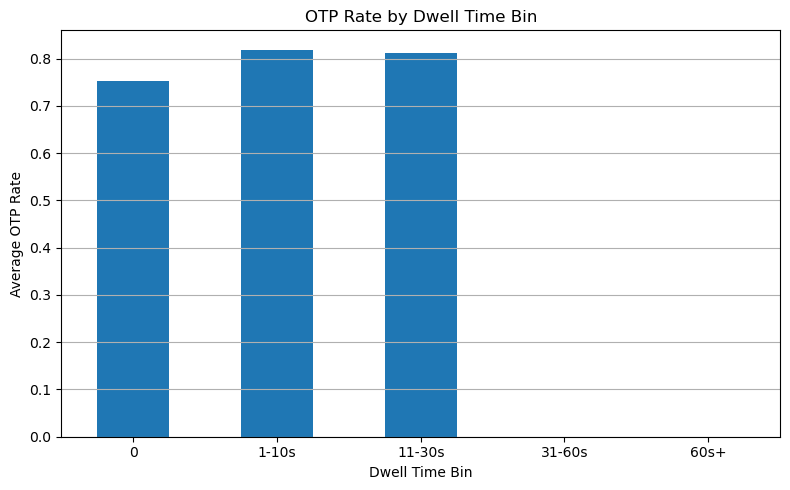

In [94]:
import matplotlib.pyplot as plt

# OTP rate by DWELL_BIN
plt.figure(figsize=(8, 5))
location_summary.groupby('DWELL_BIN')['is_OTP'].mean().plot(kind='bar')
plt.title('OTP Rate by Dwell Time Bin')
plt.ylabel('Average OTP Rate')
plt.xlabel('Dwell Time Bin')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [95]:
# STEP 9: Identify best and worst neighborhoods by average OTP rate

# Compute average OTP rate across months
otp_ranked = location_summary.groupby('NEIGHBORHOOD')['is_OTP'].mean().reset_index()

# Add trip volume for context
trip_volume = location_summary.groupby('NEIGHBORHOOD')['trip_count'].sum().reset_index()

# Merge trip volume
otp_ranked = otp_ranked.merge(trip_volume, on='NEIGHBORHOOD')

# Sort to see best and worst
otp_ranked = otp_ranked.sort_values(by='is_OTP', ascending=False)

# Preview top and bottom
print("🏅 Top 10 Neighborhoods by OTP:")
print(otp_ranked.head(10))

print("\n🚨 Bottom 10 Neighborhoods by OTP:")
print(otp_ranked.tail(10))


🏅 Top 10 Neighborhoods by OTP:
                    NEIGHBORHOOD    is_OTP  trip_count
19           SW Capitol & Sunset  0.945504         219
7    NE M L King & Killingsworth  0.865385          52
10                NW 5th & Davis  0.853803         565
14                 SW 5th & Pine  0.850883         216
20         SW Lombard & Broadway  0.814674         216
18  SW Barnes & Cedar Hills Blvd  0.802191         159
2     Clackamas Town Center Mall  0.799833        1119
9           NE M L King & Russet  0.794624         227
11                 OMSI/SE Water  0.787147         630
12              SE 82nd & Causey  0.781569         101

🚨 Bottom 10 Neighborhoods by OTP:
             NEIGHBORHOOD    is_OTP  trip_count
5    NE M L King & Bryant  0.769576         423
16        SW 6th & Salmon  0.769231          52
17    SW 6th & W Burnside  0.767078         130
8    NE M L King & Morgan  0.765553         618
4       NE Dekum & Durham  0.764706          51
1    4900 Block SW Barbur  0.756642      

In [96]:
# STEP 10: Examine drivers of best vs. worst OTP neighborhoods

# Define top and bottom performers
top_neighborhoods = otp_ranked.head(10)['NEIGHBORHOOD']
bottom_neighborhoods = otp_ranked.tail(10)['NEIGHBORHOOD']

# Filter the full summary
top_group = location_summary[location_summary['NEIGHBORHOOD'].isin(top_neighborhoods)]
bottom_group = location_summary[location_summary['NEIGHBORHOOD'].isin(bottom_neighborhoods)]

# Compare averages
comparison = pd.DataFrame({
    'Metric': ['OTP Rate', 'Avg ONS', 'Avg OFFS', 'Avg DWELL', 'Avg LOAD', 'Route Variety'],
    'Top 10 Avg': [
        top_group['is_OTP'].mean(),
        top_group['ONS'].mean(),
        top_group['OFFS'].mean(),
        top_group['DWELL'].mean(),
        top_group['ESTIMATED_LOAD'].mean(),
        top_group['ROUTE_NUMBER'].mean()
    ],
    'Bottom 10 Avg': [
        bottom_group['is_OTP'].mean(),
        bottom_group['ONS'].mean(),
        bottom_group['OFFS'].mean(),
        bottom_group['DWELL'].mean(),
        bottom_group['ESTIMATED_LOAD'].mean(),
        bottom_group['ROUTE_NUMBER'].mean()
    ]
})

comparison


,Metric,Top 10 Avg,Bottom 10 Avg
0,OTP Rate,0.823432,0.737969
1,Avg ONS,0.802133,0.220474
2,Avg OFFS,0.844749,0.223177
3,Avg DWELL,13.789155,3.651379
4,Avg LOAD,5.926966,5.907299
5,Route Variety,6.240741,3.666667


In [97]:
print("🏅 Top 5 OTP Neighborhoods:")
print(top_neighborhoods.to_list())

print("\n🚨 Bottom 5 OTP Neighborhoods:")
print(bottom_neighborhoods.to_list())


🏅 Top 5 OTP Neighborhoods:
['SW Capitol & Sunset', 'NE M L King & Killingsworth', 'NW 5th & Davis', 'SW 5th & Pine', 'SW Lombard & Broadway', 'SW Barnes & Cedar Hills Blvd', 'Clackamas Town Center Mall', 'NE M L King & Russet', 'OMSI/SE Water', 'SE 82nd & Causey']

🚨 Bottom 5 OTP Neighborhoods:
['NE M L King & Bryant', 'SW 6th & Salmon', 'SW 6th & W Burnside', 'NE M L King & Morgan', 'NE Dekum & Durham', '4900 Block SW Barbur', 'SW 6th & Harvey Milk', 'SE 82nd & King', 'NE M L King & Holland', 'Hawthorne Bridge']


In [98]:
# STEP 11: Explore OTP trends by month and neighborhood

# View monthly performance per neighborhood
monthly_trends = location_summary[['NEIGHBORHOOD', 'MONTH', 'is_OTP', 'ONS', 'OFFS', 'DWELL', 'ESTIMATED_LOAD']].copy()

# Example: see trends for a specific neighborhood (customize this name)
neighborhood_to_plot = 'Beaverton Transit Center'
trend = monthly_trends[monthly_trends['NEIGHBORHOOD'] == neighborhood_to_plot].sort_values(by='MONTH')

print(f"\n📊 Monthly OTP and metrics for: {neighborhood_to_plot}")
print(trend)



📊 Monthly OTP and metrics for: Beaverton Transit Center
Empty DataFrame
Columns: [NEIGHBORHOOD, MONTH, is_OTP, ONS, OFFS, DWELL, ESTIMATED_LOAD]
Index: []


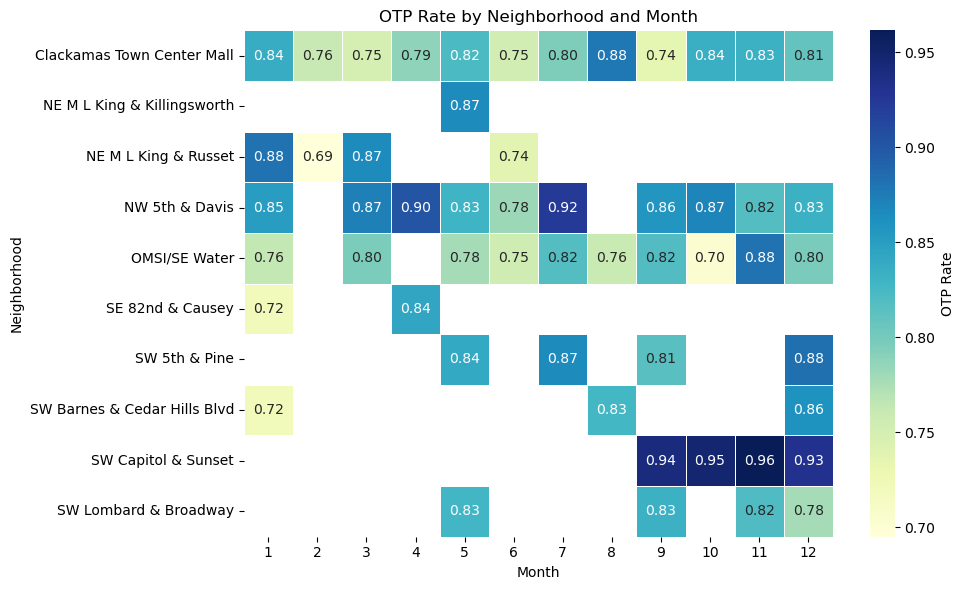

,SERVICE_DATE,LEAVE_TIME,ROUTE_NUMBER,DIRECTION,SERVICE_KEY,STOP_TIME,DWELL,ONS,OFFS,ESTIMATED_LOAD,...,PUBLOC,LATITUDE,LONGITUDE,GARAGE,MONTH,DELAY_MINUTES,is_OTP,DWELL_BIN,LOAD_BIN,NEIGHBORHOOD
32804674,2023-01-26,34017,4,1,W,33999,7,1,0,16,...,N Vancouver & Tillamook,45.538121,-122.667792,CENTER,1,0.300000,1,1-10s,11-30,N Vancouver & Tillamook
24378842,2023-02-11,34714,78,1,S,34666,0,0,0,1,...,SW Denney & 111th,45.469412,-122.790516,MERLO,2,0.800000,1,0,0-10,SW Denney & 111th
58570612,2023-06-26,81398,56,1,W,81275,0,0,0,3,...,6500 Block SW Beaverton-Hillsdale,45.486956,-122.744400,MERLO,6,2.050000,1,0,0-10,6500 Block SW Beaverton-Hillsdale
11495163,2023-06-03,60938,33,0,S,60720,15,1,1,11,...,SE McLoughlin & Jennings,45.390596,-122.612611,CENTER,6,3.633333,1,11-30s,11-30,SE McLoughlin & Jennings
22320557,2023-08-01,53203,78,1,W,53268,0,0,0,12,...,SW 68th & Franklin,45.430404,-122.746911,MERLO,8,-1.083333,0,0,11-30,SW 68th & Franklin


In [99]:
# STEP 11: Visualize OTP by Neighborhood and Month as Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot OTP by neighborhood and month
otp_heatmap = location_summary.pivot(index='NEIGHBORHOOD', columns='MONTH', values='is_OTP')

# Optional: focus on top 10 neighborhoods only
top_10_neighs = otp_ranked.head(10)['NEIGHBORHOOD'].tolist()
otp_heatmap = otp_heatmap.loc[otp_heatmap.index.isin(top_10_neighs)]

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(otp_heatmap, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'OTP Rate'})
plt.title("OTP Rate by Neighborhood and Month")
plt.ylabel("Neighborhood")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

df.head()

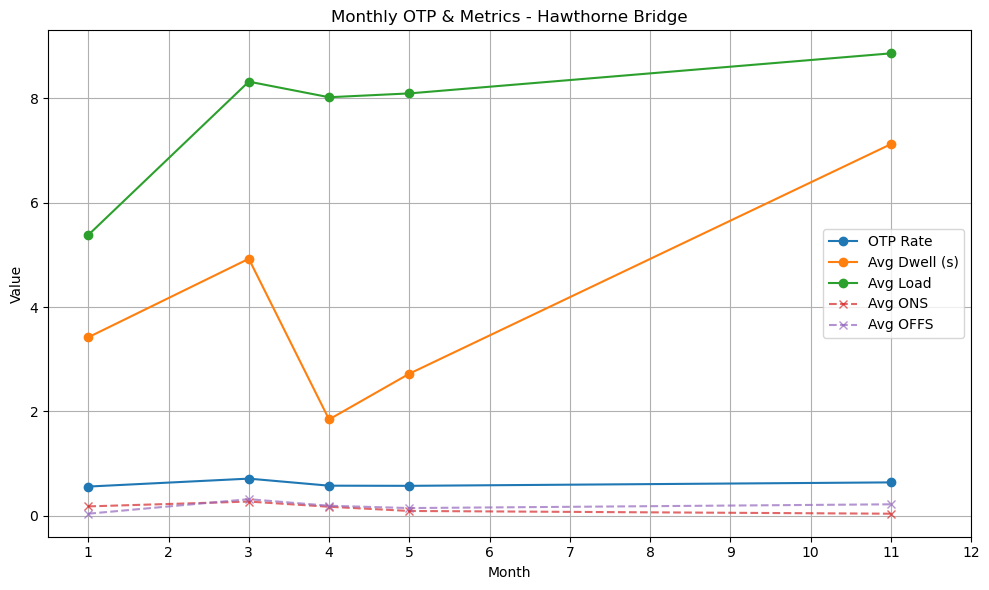

In [111]:
# Line chart for monthly OTP and drivers for a specific neighborhood
neighborhood_to_plot = 'Hawthorne Bridge'

subset = location_summary[location_summary['NEIGHBORHOOD'] == neighborhood_to_plot].sort_values('MONTH')

plt.figure(figsize=(10, 6))
plt.plot(subset['MONTH'], subset['is_OTP'], label='OTP Rate', marker='o')
plt.plot(subset['MONTH'], subset['DWELL'], label='Avg Dwell (s)', marker='o')
plt.plot(subset['MONTH'], subset['ESTIMATED_LOAD'], label='Avg Load', marker='o')
plt.plot(subset['MONTH'], subset['ONS'], label='Avg ONS', linestyle='--', marker='x', alpha=0.7)
plt.plot(subset['MONTH'], subset['OFFS'], label='Avg OFFS', linestyle='--', marker='x', alpha=0.7)

plt.title(f"Monthly OTP & Metrics - {neighborhood_to_plot}")
plt.xlabel("Month")
plt.ylabel("Value")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [101]:
# STEP 12: See key driver metrics for each Top 5 and Bottom 5 neighborhood

# Combine both groups into one dataframe
combined_neighborhoods = pd.concat([top_group, bottom_group])

# Group by neighborhood and calculate means
neighborhood_metrics = combined_neighborhoods.groupby('NEIGHBORHOOD').agg({
    'is_OTP': 'mean',
    'ONS': 'mean',
    'OFFS': 'mean',
    'DWELL': 'mean',
    'ESTIMATED_LOAD': 'mean',
    'ROUTE_NUMBER': 'nunique'
}).rename(columns={
    'is_OTP': 'OTP Rate',
    'ONS': 'Avg ONS',
    'OFFS': 'Avg OFFS',
    'DWELL': 'Avg DWELL',
    'ESTIMATED_LOAD': 'Avg LOAD',
    'ROUTE_NUMBER': 'Route Variety'
}).reset_index()

# Sort so Top 5 appear first, then Bottom 5
neighborhood_metrics['Group'] = neighborhood_metrics['NEIGHBORHOOD'].apply(
    lambda x: 'Top 5' if x in top_neighborhoods.values else 'Bottom 5'
)

neighborhood_metrics = neighborhood_metrics.sort_values(by='Group', ascending=False)

neighborhood_metrics

,NEIGHBORHOOD,OTP Rate,Avg ONS,Avg OFFS,Avg DWELL,Avg LOAD,Route Variety,Group
10,OMSI/SE Water,0.787147,0.373660,0.348292,8.636023,8.935038,3,Top 5
8,NE M L King & Russet,0.794624,0.525139,0.690491,8.422761,4.848048,1,Top 5
18,SW Capitol & Sunset,0.945504,0.762521,1.343543,20.119567,5.850338,2,Top 5
17,SW Barnes & Cedar Hills Blvd,0.802191,0.082672,0.185362,1.999303,5.170364,1,Top 5
13,SW 5th & Pine,0.850883,0.888739,1.408697,19.086289,6.504929,2,Top 5
11,SE 82nd & Causey,0.781569,0.603333,0.513922,8.708431,6.324510,1,Top 5
1,Clackamas Town Center Mall,0.799833,1.535681,1.531378,20.760998,3.980044,3,Top 5
9,NW 5th & Davis,0.853803,0.785721,0.555245,15.672573,5.113007,1,Top 5
19,SW Lombard & Broadway,0.814674,0.398608,0.438378,5.886028,6.345070,1,Top 5
6,NE M L King & Killingsworth,0.865385,1.538462,1.096154,14.923077,9.461538,1,Top 5


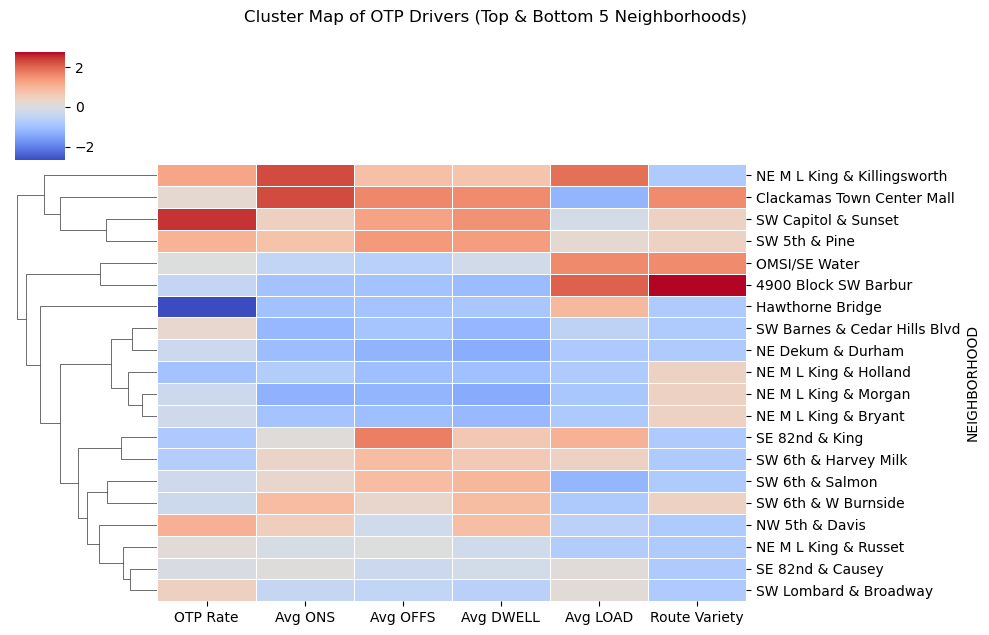

In [102]:
# STEP 13: Cluster map of OTP drivers for Top & Bottom neighborhoods
from seaborn import clustermap
import seaborn as sns

# Select only numeric columns to cluster
cluster_data = neighborhood_metrics.set_index('NEIGHBORHOOD')[
    ['OTP Rate', 'Avg ONS', 'Avg OFFS', 'Avg DWELL', 'Avg LOAD', 'Route Variety']
]

# Standardize values (optional but helps scale balance)
from sklearn.preprocessing import StandardScaler
scaled_data = pd.DataFrame(
    StandardScaler().fit_transform(cluster_data),
    index=cluster_data.index,
    columns=cluster_data.columns
)

# Plot clustermap
sns.clustermap(
    scaled_data,
    cmap="coolwarm",
    figsize=(10, 6),
    standard_scale=None,
    linewidths=0.5,
    row_cluster=True,
    col_cluster=False  # Optional: disable if you want fixed column order
)

plt.suptitle("Cluster Map of OTP Drivers (Top & Bottom 5 Neighborhoods)", y=1.05)
plt.show()

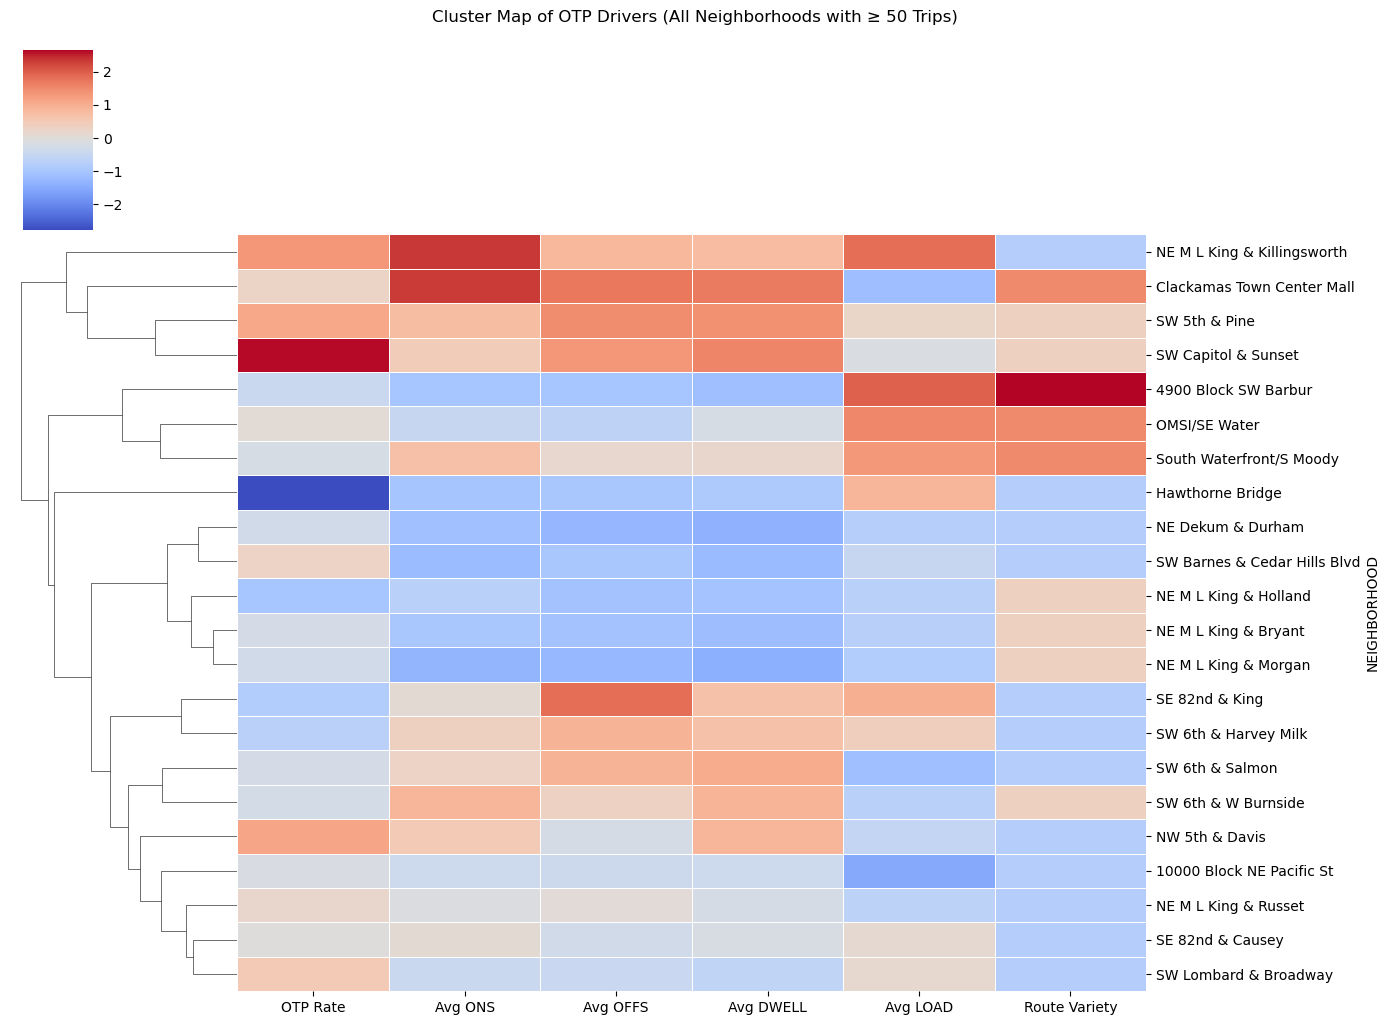

In [107]:
# STEP 14: Cluster map of OTP drivers for all non-transit neighborhoods with ≥ 50 trips
from seaborn import clustermap
from sklearn.preprocessing import StandardScaler

# Filter non-transit neighborhoods with sufficient data
eligible_neighborhoods = location_summary[location_summary['trip_count'] >= 50].copy()

# Group and prepare OTP driver metrics
full_cluster_data = eligible_neighborhoods.groupby('NEIGHBORHOOD').agg({
    'is_OTP': 'mean',
    'ONS': 'mean',
    'OFFS': 'mean',
    'DWELL': 'mean',
    'ESTIMATED_LOAD': 'mean',
    'ROUTE_NUMBER': 'nunique'
}).rename(columns={
    'is_OTP': 'OTP Rate',
    'ONS': 'Avg ONS',
    'OFFS': 'Avg OFFS',
    'DWELL': 'Avg DWELL',
    'ESTIMATED_LOAD': 'Avg LOAD',
    'ROUTE_NUMBER': 'Route Variety'
})

# Scale values for clustering
scaled_full = pd.DataFrame(
    StandardScaler().fit_transform(full_cluster_data),
    index=full_cluster_data.index,
    columns=full_cluster_data.columns
)

# Create the clustermap
sns.clustermap(
    scaled_full,
    cmap="coolwarm",
    figsize=(14, 10),
    linewidths=0.5,
    row_cluster=True,
    col_cluster=False
)

plt.suptitle("Cluster Map of OTP Drivers (All Neighborhoods with ≥ 50 Trips)", y=1.02)
plt.show()


In [109]:
eligible_neighborhoods.shape


(111, 12)

In [113]:
location_summary[['ROUTE_NUMBER', 'is_OTP']].corr()

,ROUTE_NUMBER,is_OTP
ROUTE_NUMBER,1.000000,0.297043
is_OTP,0.297043,1.000000


In [115]:
location_summary[['ROUTE_NUMBER', 'is_OTP']].corr().iloc[0,1]

0.29704341692782593

In [117]:
location_summary.to_csv("/Users/kathypresto/Desktop/location_summary_2023-2024.csv", index=False)